# Gradient Descent for Linear Regression

## Objective
Find the **best-fitting line** through data points by minimizing the **Mean Squared Error (MSE)**:

$$L(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$$

### Update Rules
$$m_{new} = m - \alpha \cdot \frac{\partial L}{\partial m}, \quad b_{new} = b - \alpha \cdot \frac{\partial L}{\partial b}$$

where:
$$\frac{\partial L}{\partial m} = -\frac{2}{n} \sum x_i(y_i - (mx_i + b)), \quad \frac{\partial L}{\partial b} = -\frac{2}{n} \sum (y_i - (mx_i + b))$$

## Section 1: Generate Data

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# True line: y = 2.5x + 3
n_points = 50
true_slope = 2.5
true_intercept = 3.0

x = np.linspace(0, 10, n_points)
noise = np.random.normal(0, 2, n_points)
y = true_slope * x + true_intercept + noise

print(f"Generated {n_points} data points")
print(f"True line: y = {true_slope}x + {true_intercept}")
print(f"x range: [{x.min():.1f}, {x.max():.1f}]")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

Generated 50 data points
True line: y = 2.5x + 3.0
x range: [0.0, 10.0]
y range: [3.2, 29.1]


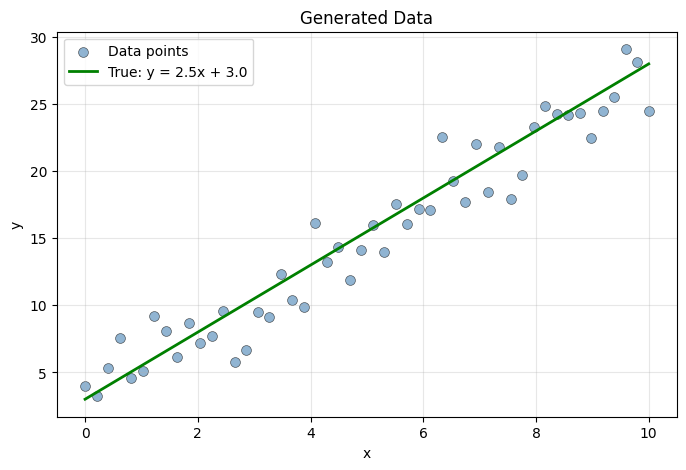

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5, label='Data points')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, true_slope * x_line + true_intercept, 'g-', linewidth=2, label=f'True: y = {true_slope}x + {true_intercept}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Section 2: Loss Function and Gradients

In [18]:
def loss_function(x_data, y_data, m, b):
    """MSE loss: L = (1/n) * sum((y - (mx + b))^2)"""
    y_pred = m * x_data + b
    return np.mean((y_data - y_pred) ** 2)

def compute_gradients(x_data, y_data, m, b):
    """Gradients of MSE w.r.t. m and b"""
    n = len(x_data)
    residuals = y_data - (m * x_data + b)
    grad_m = -2.0 / n * np.sum(x_data * residuals)
    grad_b = -2.0 / n * np.sum(residuals)
    return grad_m, grad_b

# Quick test
loss = loss_function(x, y, 1.0, 1.0)
grad_m, grad_b = compute_gradients(x, y, 1.0, 1.0)
print(f"At m=1.0, b=1.0:")
print(f"  Loss = {loss:.4f}")
print(f"  ∂L/∂m = {grad_m:.4f}")
print(f"  ∂L/∂b = {grad_b:.4f}")

At m=1.0, b=1.0:
  Loss = 101.8004
  ∂L/∂m = -114.4993
  ∂L/∂b = -18.0981


## Section 3: Gradient Descent

In [19]:
def gradient_descent(x_data, y_data, m_init, b_init, learning_rate, num_iterations):
    m, b = m_init, b_init
    history_m, history_b = [m], [b]
    history_loss = [loss_function(x_data, y_data, m, b)]
    
    for _ in range(num_iterations):
        grad_m, grad_b = compute_gradients(x_data, y_data, m, b)
        m = m - learning_rate * grad_m
        b = b - learning_rate * grad_b
        
        history_m.append(m)
        history_b.append(b)
        history_loss.append(loss_function(x_data, y_data, m, b))
    
    return np.array(history_m), np.array(history_b), np.array(history_loss)

print("Gradient descent function defined!")

Gradient descent function defined!


## Section 4: Run with Different Learning Rates

In [20]:
learning_rates = [0.001, 0.005, 0.01]
num_iterations = 200
results = {}

for lr in learning_rates:
    m_hist, b_hist, loss_hist = gradient_descent(x, y, 0.0, 0.0, lr, num_iterations)
    results[lr] = {
        'm_history': m_hist, 'b_history': b_hist, 'loss_history': loss_hist,
        'final_m': m_hist[-1], 'final_b': b_hist[-1], 'final_loss': loss_hist[-1]
    }
    print(f"α={lr}: m={m_hist[-1]:.4f}, b={b_hist[-1]:.4f}, loss={loss_hist[-1]:.4f}")

α=0.001: m=2.7508, b=0.6774, loss=4.8488
α=0.005: m=2.6289, b=1.4918, loss=3.9910
α=0.01: m=2.5317, b=2.1417, loss=3.5516


## Section 5: Visualize Convergence

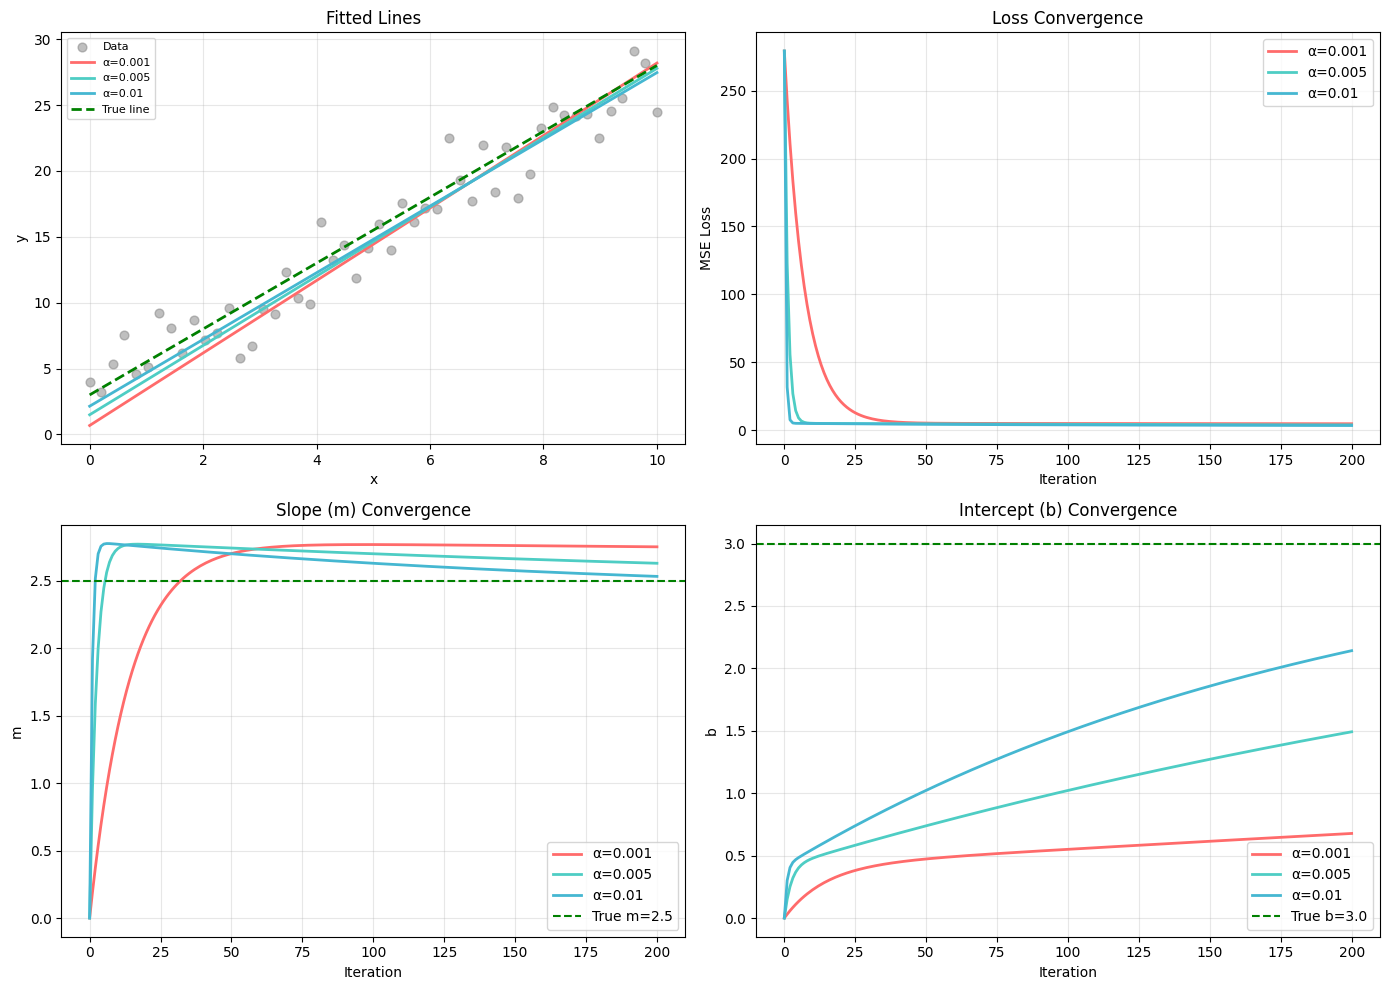

In [21]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fitted lines
ax = axes[0, 0]
ax.scatter(x, y, alpha=0.5, s=40, color='gray', label='Data')
x_line = np.linspace(x.min(), x.max(), 100)
for i, lr in enumerate(learning_rates):
    m, b = results[lr]['final_m'], results[lr]['final_b']
    ax.plot(x_line, m * x_line + b, color=colors[i], linewidth=2, label=f'α={lr}')
ax.plot(x_line, true_slope * x_line + true_intercept, 'g--', linewidth=2, label='True line')
ax.set_title('Fitted Lines')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Loss convergence
ax = axes[0, 1]
for i, lr in enumerate(learning_rates):
    ax.plot(results[lr]['loss_history'], color=colors[i], linewidth=2, label=f'α={lr}')
ax.set_title('Loss Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Slope convergence
ax = axes[1, 0]
for i, lr in enumerate(learning_rates):
    ax.plot(results[lr]['m_history'], color=colors[i], linewidth=2, label=f'α={lr}')
ax.axhline(y=true_slope, color='green', linestyle='--', label=f'True m={true_slope}')
ax.set_title('Slope (m) Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('m')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Intercept convergence
ax = axes[1, 1]
for i, lr in enumerate(learning_rates):
    ax.plot(results[lr]['b_history'], color=colors[i], linewidth=2, label=f'α={lr}')
ax.axhline(y=true_intercept, color='green', linestyle='--', label=f'True b={true_intercept}')
ax.set_title('Intercept (b) Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('b')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Compare with Analytical Solution

In [22]:
# Analytical solution (Normal Equations)
n = len(x)
m_analytical = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
b_analytical = (np.sum(y) - m_analytical * np.sum(x)) / n
loss_analytical = loss_function(x, y, m_analytical, b_analytical)

print(f"{'Method':<25} {'m':>10} {'b':>10} {'Loss':>10}")
print("-" * 58)
print(f"{'True parameters':<25} {true_slope:>10.4f} {true_intercept:>10.4f} {'':>10}")
print(f"{'Analytical':<25} {m_analytical:>10.4f} {b_analytical:>10.4f} {loss_analytical:>10.4f}")
for lr in learning_rates:
    r = results[lr]
    print(f"{'GD (α=' + str(lr) + ')':<25} {r['final_m']:>10.4f} {r['final_b']:>10.4f} {r['final_loss']:>10.4f}")

print()
print("Note: Gradient descent approaches the analytical solution.")
print("Larger learning rates converge faster but need more iterations for the intercept.")

Method                             m          b       Loss
----------------------------------------------------------
True parameters               2.5000     3.0000           
Analytical                    2.3840     3.1289     3.3006
GD (α=0.001)                  2.7508     0.6774     4.8488
GD (α=0.005)                  2.6289     1.4918     3.9910
GD (α=0.01)                   2.5317     2.1417     3.5516

Note: Gradient descent approaches the analytical solution.
Larger learning rates converge faster but need more iterations for the intercept.


## Section 7: Effect of Iterations on Convergence

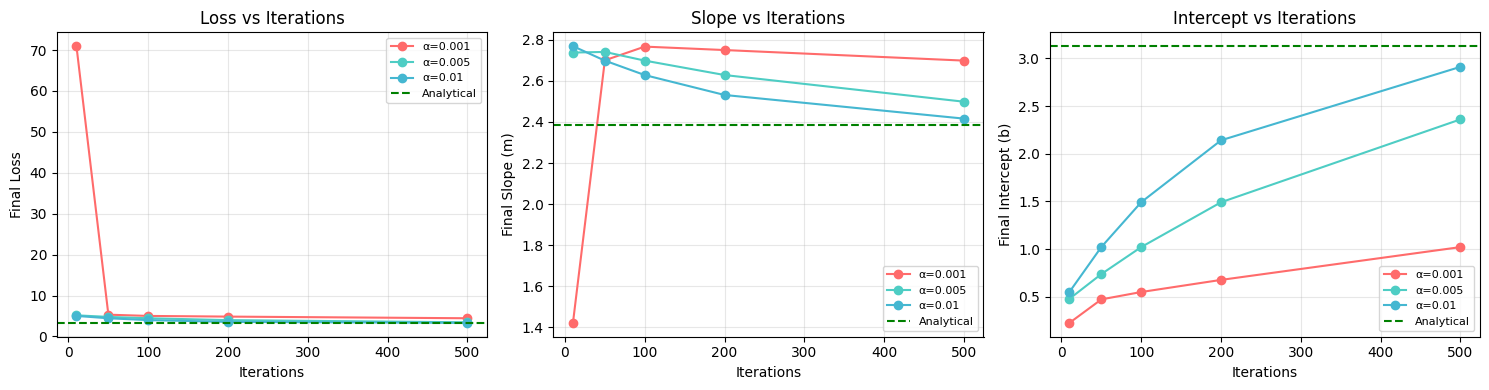

Observations:
- Larger learning rates converge faster (fewer iterations needed)
- Smaller learning rates need more iterations but converge more smoothly
- All learning rates eventually approach the analytical solution


In [23]:
iteration_counts = [10, 50, 100, 200, 500]
iter_results = {}

for lr in learning_rates:
    iter_results[lr] = {'loss': [], 'm': [], 'b': []}
    for n_iter in iteration_counts:
        m_h, b_h, l_h = gradient_descent(x, y, 0.0, 0.0, lr, n_iter)
        iter_results[lr]['loss'].append(l_h[-1])
        iter_results[lr]['m'].append(m_h[-1])
        iter_results[lr]['b'].append(b_h[-1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss vs iterations
for i, lr in enumerate(learning_rates):
    axes[0].plot(iteration_counts, iter_results[lr]['loss'], 'o-', color=colors[i], label=f'α={lr}')
axes[0].axhline(y=loss_analytical, color='green', linestyle='--', label='Analytical')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Final Loss')
axes[0].set_title('Loss vs Iterations')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Slope vs iterations
for i, lr in enumerate(learning_rates):
    axes[1].plot(iteration_counts, iter_results[lr]['m'], 'o-', color=colors[i], label=f'α={lr}')
axes[1].axhline(y=m_analytical, color='green', linestyle='--', label='Analytical')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Final Slope (m)')
axes[1].set_title('Slope vs Iterations')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Intercept vs iterations
for i, lr in enumerate(learning_rates):
    axes[2].plot(iteration_counts, iter_results[lr]['b'], 'o-', color=colors[i], label=f'α={lr}')
axes[2].axhline(y=b_analytical, color='green', linestyle='--', label='Analytical')
axes[2].set_xlabel('Iterations')
axes[2].set_ylabel('Final Intercept (b)')
axes[2].set_title('Intercept vs Iterations')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("- Larger learning rates converge faster (fewer iterations needed)")
print("- Smaller learning rates need more iterations but converge more smoothly")
print("- All learning rates eventually approach the analytical solution")